In [15]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [14, 16]



In [16]:
target_files = [
    "CRMLSSold202512.csv",
    "CRMLSSold202601.csv",
    "CRMLSSold202602.csv",
    "CRMLSSold202603.csv",
    "CRMLSSold202604.csv",
    "CRMLSSold202605.csv"
]

data_path = "../DS intern file" 

df_list = []
for file_name in target_files:
    file_key = os.path.join(data_path, file_name)
    if os.path.exists(file_key):
        temp_df = pd.read_csv(file_key, low_memory=False)
        df_list.append(temp_df)
        print("completed")
    else:
        print("can not find file")


df = pd.concat(df_list, ignore_index=True)

completed
completed
completed
completed
completed
completed


In [17]:
filtered_df = df[
    (df['PropertyType'] == 'Residential') & 
    (df['PropertySubType'] == 'SingleFamilyResidence')
].copy()

filtered_df.head()

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,LotSizeDimensions,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict
0,ContraCosta,ContraCosta,"Carpet,Tile,Wood",NaN,NaN,NaN,False,1998000.0,1150041639,teresa@teresahooper.com,...,NaN,10080.0,NaN,False,3.0,San Ramon Valley,94596,975.0,10080.0,NaN
2,SanDiego,SanDiego,"Carpet,Wood",True,NaN,NaN,False,2214421.0,1150038683,laura@lauralothianrealestate.com,...,NaN,34745.0,NaN,False,3.0,NaN,91364,NaN,34745.0,NaN
3,Mlslistings,Mlslistings,NaN,False,NaN,NaN,NaN,1200000.0,1150038607,trung.lam@kw.com,...,NaN,6600.0,NaN,False,2.0,Other,95121,NaN,6600.0,NaN
7,Mlslistings,Mlslistings,NaN,False,NaN,NaN,NaN,3100000.0,1150032869,vickie@realsmartgroup.com,...,NaN,8262.0,NaN,False,1.0,San Jose Unified,95124,NaN,8262.0,NaN
9,Mlslistings,Mlslistings,NaN,False,NaN,NaN,NaN,2900000.0,1150028403,vickie@realsmartgroup.com,...,NaN,9222.0,NaN,False,2.0,Other,95128,NaN,9222.0,NaN


In [24]:
def find_column(df, keywords, default_name):
    for col in df.columns:
        if any(kw.lower() in col.lower() for kw in keywords):
            return col
    return default_name

price_col = find_column(filtered_df, ['ClosePrice'], 'ClosePrice')
living_col = find_column(filtered_df, ['LivingArea'], 'LivingArea')
beds_col = find_column(filtered_df, ['BedroomsTotal', 'MainLevelBedrooms', 'Bedrooms'], 'Bedrooms')
baths_col = find_column(filtered_df, ['BathroomsTotal', 'BathroomsFull', 'Bathrooms'], 'Bathrooms')
lot_col = find_column(filtered_df, ['LotSizeSquareFeet', 'LotSizeArea', 'LotSize'], 'LotSize')

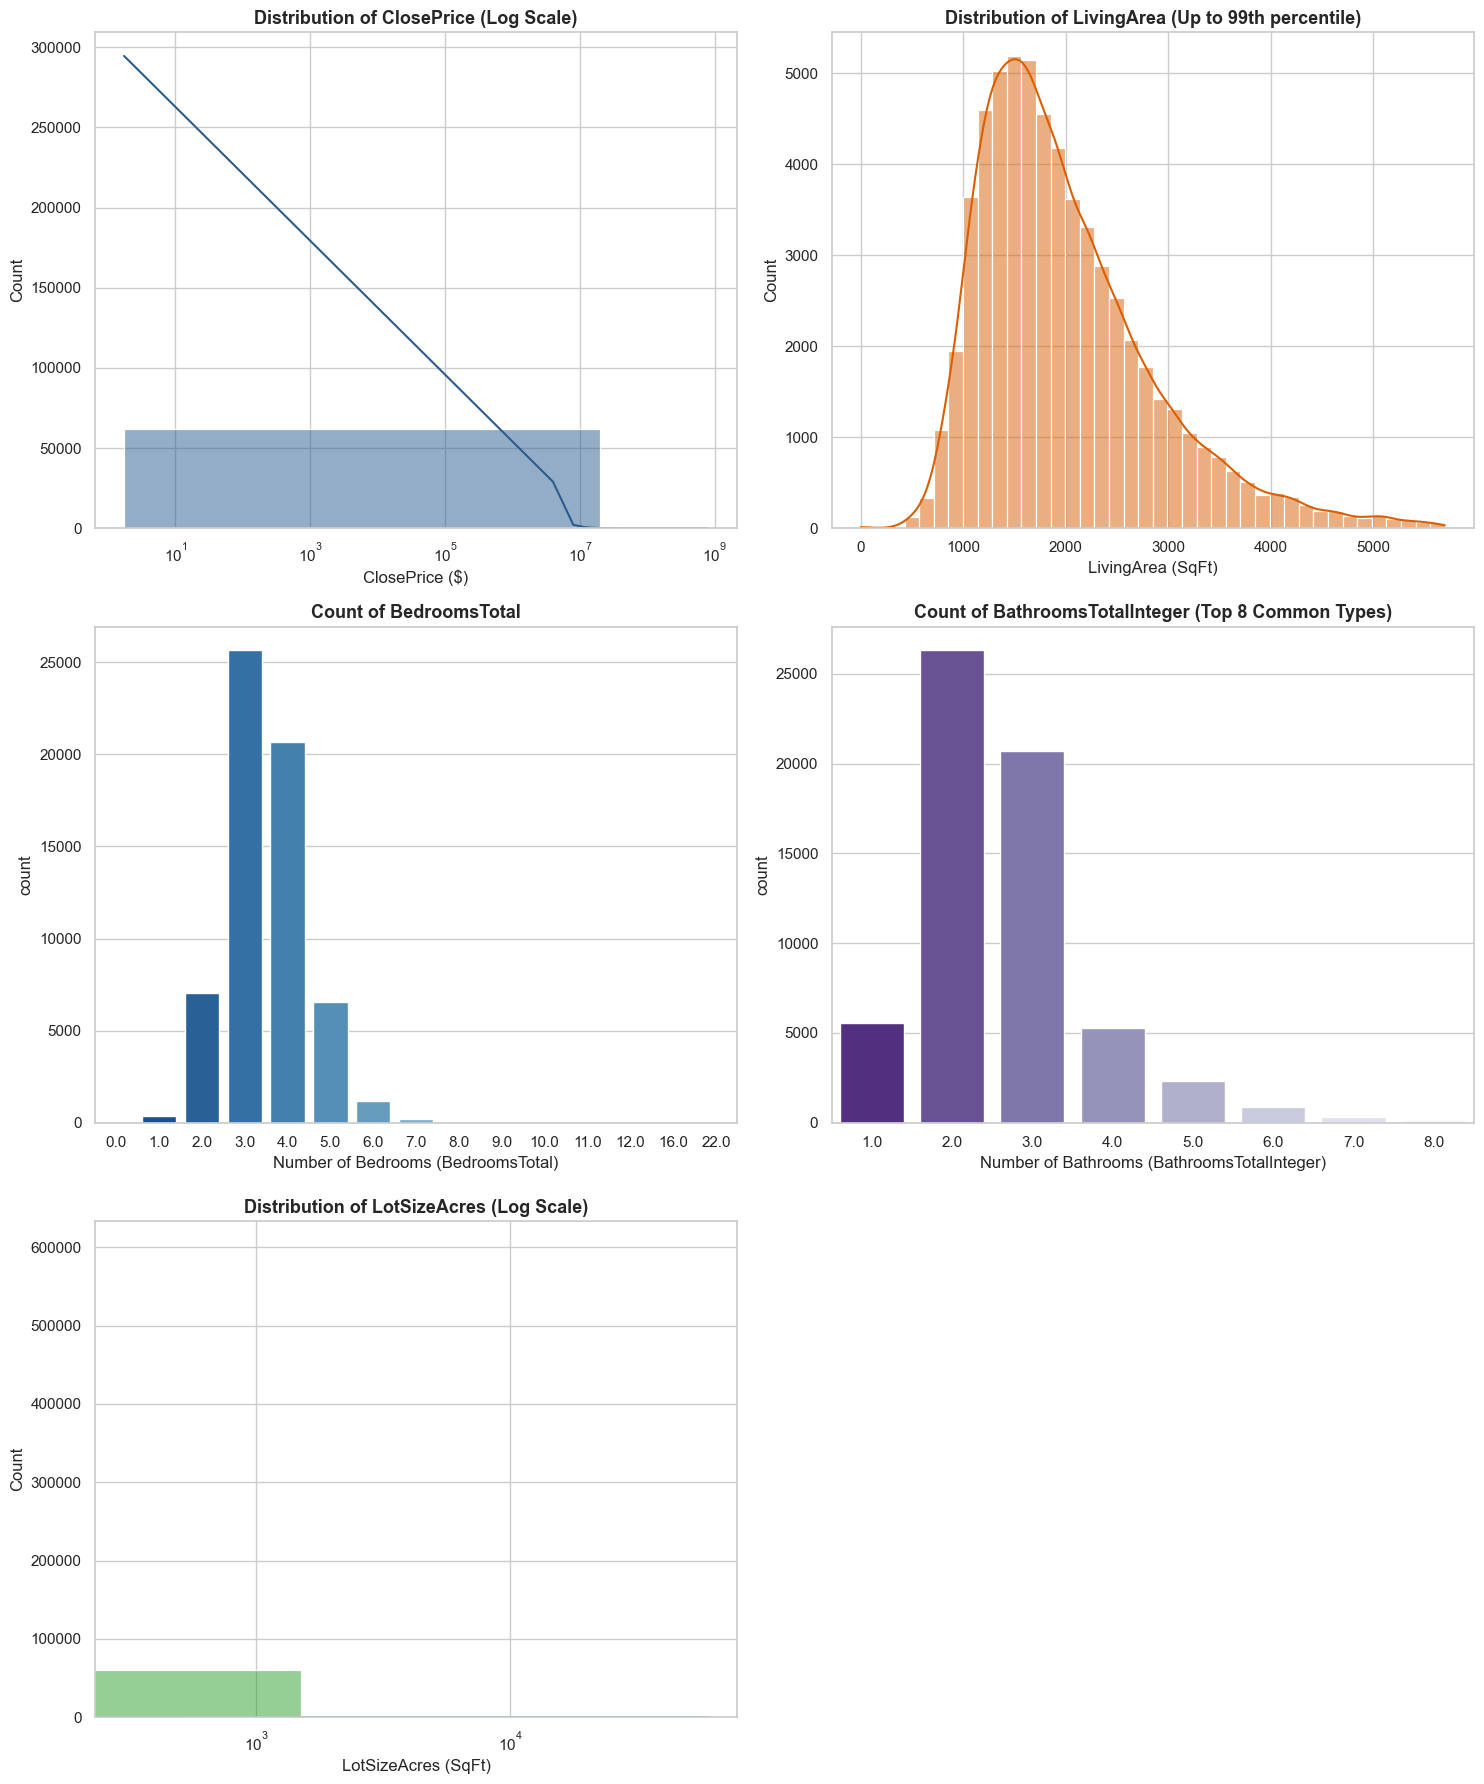

In [25]:



# EDA plots
fig, axes = plt.subplots(3, 2, figsize=(15, 18))
axes = axes.flatten()

# (1) ClosePrice
if price_col in filtered_df.columns:
    sns.histplot(filtered_df[price_col], bins=40, kde=True, ax=axes[0], color='#2b5c8f')
    axes[0].set_title(f'Distribution of {price_col} (Log Scale)', fontsize=13, fontweight='bold')
    axes[0].set_xscale('log')
    axes[0].set_xlabel(f'{price_col} ($)')

# (2) LivingArea
if living_col in filtered_df.columns:
    q_living = filtered_df[living_col].quantile(0.99)
    sns.histplot(filtered_df[filtered_df[living_col] <= q_living][living_col], bins=40, kde=True, ax=axes[1], color='#d95f02')
    axes[1].set_title(f'Distribution of {living_col} (Up to 99th percentile)', fontsize=13, fontweight='bold')
    axes[1].set_xlabel(f'{living_col} (SqFt)')

# (3) Bedrooms
if beds_col in filtered_df.columns:
    sns.countplot(data=filtered_df, x=beds_col, ax=axes[2], palette='Blues_r')
    axes[2].set_title(f'Count of {beds_col}', fontsize=13, fontweight='bold')
    axes[2].set_xlabel(f'Number of Bedrooms ({beds_col})')

# (4) Bathrooms
if baths_col in filtered_df.columns:
    top_baths = filtered_df[baths_col].value_counts().iloc[:8].index
    sns.countplot(data=filtered_df[filtered_df[baths_col].isin(top_baths)], x=baths_col, ax=axes[3], palette='Purples_r')
    axes[3].set_title(f'Count of {baths_col} (Top 8 Common Types)', fontsize=13, fontweight='bold')
    axes[3].set_xlabel(f'Number of Bathrooms ({baths_col})')

# (5) LotSize
if lot_col in filtered_df.columns:
    sns.histplot(filtered_df[lot_col], bins=40, kde=True, ax=axes[4], color='#2ca02c')
    axes[4].set_title(f'Distribution of {lot_col} (Log Scale)', fontsize=13, fontweight='bold')
    axes[4].set_xscale('log')
    axes[4].set_xlabel(f'{lot_col} (SqFt)')
    
axes[5].axis('off')

plt.tight_layout()
plt.show()

In [23]:
# Summurize Satistics
target_cols = [col for col in [price_col, living_col, beds_col, baths_col, lot_col] if col in filtered_df.columns]
print(filtered_df[target_cols].describe().round(2))

         ClosePrice  LivingArea  BedroomsTotal  BathroomsTotalInteger  \
count  6.172700e+04    61697.00       61727.00               61726.00   
mean   1.340106e+06     2055.55           3.50                   2.64   
std    7.307629e+06     1037.24           0.97                   1.14   
min    1.750000e+00        0.00           0.00                   0.00   
25%    6.200000e+05     1386.00           3.00                   2.00   
50%    8.900000e+05     1826.00           3.00                   2.00   
75%    1.425000e+06     2455.00           4.00                   3.00   
max    7.960000e+08    23314.00          22.00                  22.00   

       LotSizeAcres  
count      60644.00  
mean          10.83  
std          544.53  
min            0.00  
25%            0.13  
50%            0.17  
75%            0.24  
max        60113.00  
